# Random Forest Classifier

This notebook demonstrates training and evaluating a Random Forest Classifier to predict the presence arsnenic based on item features including document type (`doc_type`), city of origin (`city`), country of origin (`country`), year of origin (`year`), room within storage location (`loc_room`), general storage location (`loc_gen`), and collection (`collection`). 

The pipeline includes data preprocessing, model training, cross-validation, and feature importance analysis.

The steps are the exact same as the pipline for Gradient Boosting classifier, only difference is in the parameter tuning.

## 1. Import everything

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 2. Load and explore the data

We begin by loading the dataset from an Excel file and preparing it for modeling. We print out the first 5 rows to showcase the structure of the dataset.


In [13]:
#Load the data
df = pd.read_excel('new_result_v1.xlsx')

#df.head() #Prints first 5 rows of the DataFrame by default, this is commented out for the public version on GitHub

## 3. Define Features and Target

We separate the target variable `result` from the features, and identify categorical and numeric columns.

In [14]:
#Define features and target
X = df.drop(columns=['result'])
y = df['result']

#Define categorical and numeric columns
categorical_cols = ['doc_type', 'city', 'country', 'loc_gen', 'loc_room', 'publisher', 'room_no', 'collection']
numeric_cols = ['year']

## 4. Preprocessing and Model Pipeline

We create a preprocessing pipeline using `ColumnTransformer` and `OneHotEncoder` for categorical features, then combine it with a `RandomForestClassifier`.


In [15]:
#Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
    force_int_remainder_cols=False  # future-prove due to warnings
)

#Combine with classifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=800, #more than 800 yeild the same evaluation results with increased training time
        class_weight='balanced', 
        #adding balanced classweight only made a minor difference to recall of class 1
        random_state=42, #42 is just a random seed
    ))
]) 

## 5. Cross-Validation and Model Evaluation

We use Stratified K-Fold cross-validation to preserve class balance across folds, by ensuring each split have the same proportion as the overall dataset Multiple metrics are computed to evaluate model performance.


In [16]:
#Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

#Evaluate using multiple metrics
scores = cross_validate(
    clf_pipeline,
    X, y,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True
)

#Split into train/test, this is later used for feature importance analysis
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Classification Report

We generate predictions across all folds and compute a classification report showing per-class precision, recall, and F1-score. A discussion of these results can be found in Section 6.5 of the thesis.

In [17]:
#Get predicted labels across all CV folds
y_pred_cv = cross_val_predict(clf_pipeline, X, y, cv=cv)

#Show full classification report
print(classification_report(y, y_pred_cv))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       923
           1       0.75      0.66      0.70       495

    accuracy                           0.80      1418
   macro avg       0.79      0.77      0.78      1418
weighted avg       0.80      0.80      0.80      1418



## confusion matrix
To visualise the classification results, the confusion matrix is plotted. Discussion can also be found in Section 6.5.

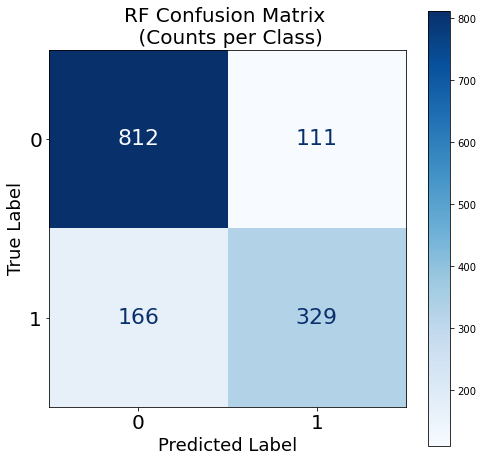

In [18]:
#Compute confusion matrix using cross-validated predictions
cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())  #'d' shows integer counts

#Add axis labels with larger fonts
plt.xlabel('Predicted Label', fontsize=18)
plt.ylabel('True Label', fontsize=18)

#Increase font size of numbers inside the matrix
ax = plt.gca()
for text in ax.texts:
    text.set_fontsize(22)

#Increase font size of tick labels (0 and 1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.title('RF Confusion Matrix \n (Counts per Class)', fontsize=20)
#plt.savefig('new_RF_cm_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance Analysis

## 7. Detailed Feature Importance

Shape of transformed X_train: (1134, 867)
Feature names: 867
Importances: 867


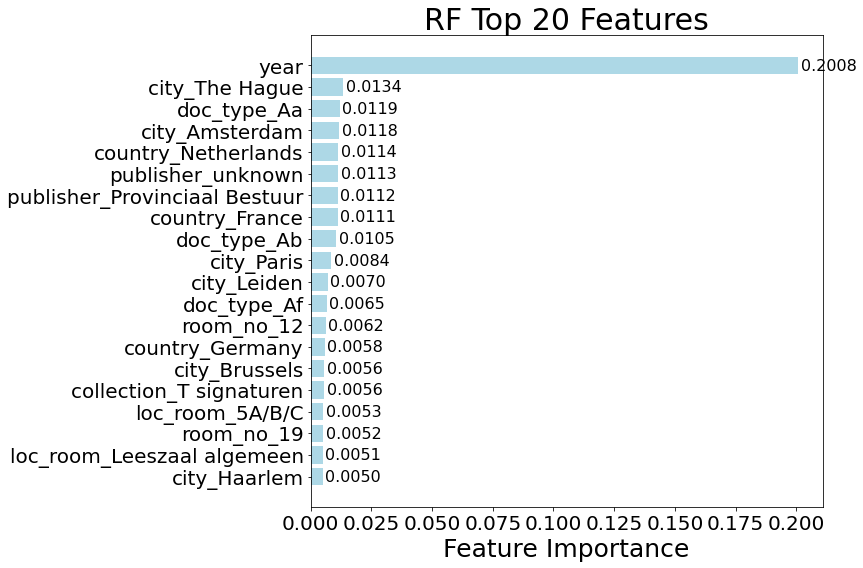

In [8]:
#Fit on training data
clf_pipeline.fit(X_train, y_train)

#Extract trained model
model = clf_pipeline.named_steps['classifier']
preprocessor = clf_pipeline.named_steps['preprocessor']

#Fit preprocessor separately to get features
preprocessor.fit(X_train)

#Get encoded feature names
cat_transformer = preprocessor.named_transformers_['cat']
encoded_cat_features = cat_transformer.get_feature_names_out(categorical_cols)

#Get numeric features from remainder
remainder_cols = preprocessor.transformers_[-1][2]
numeric_features = [X.columns[i] if isinstance(i, int) else i for i in remainder_cols]

#Full feature list in order
all_feature_names = list(encoded_cat_features) + numeric_features

#Confirm match
importances = model.feature_importances_
X_train_transformed = preprocessor.transform(X_train)

print("Shape of transformed X_train:", X_train_transformed.shape)
print("Feature names:", len(all_feature_names))
print("Importances:", len(importances))

#Create DataFrame
feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)


#Plot
plt.figure(figsize=(12, 8))
bars = plt.barh(feat_imp['feature'][:20][::-1], feat_imp['importance'][:20][::-1], color='#ADD8E6')
plt.xlabel("Feature Importance", fontsize=25)
plt.title("RF Top 20 Features", fontsize=30)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)

#Add importance score labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{width:.4f}", fontsize=16, va='center')
    
plt.tight_layout()
#plt.savefig('RF_features.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Grouped Feature Importance

original_feature
publisher     0.443712
year          0.200796
city          0.166118
country       0.053800
doc_type      0.038258
room_no       0.028530
loc_room      0.027244
collection    0.026795
loc_gen       0.014747
Name: importance, dtype: float64


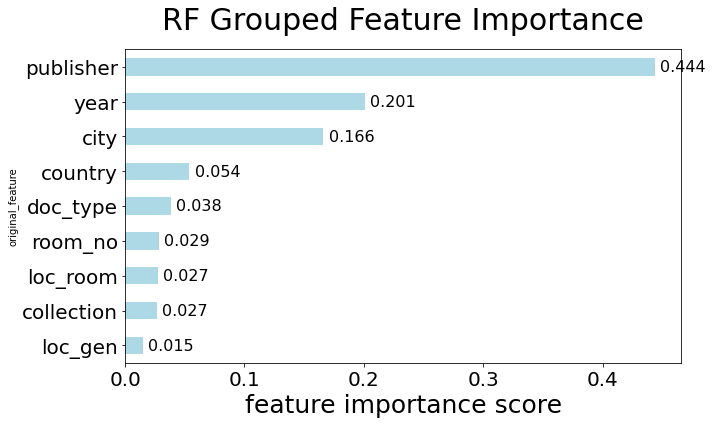

In [9]:
#Helper function - extract original column
def get_original_col(feature_name):
    # Check for multi-word feature names first
    for col in categorical_cols + numeric_cols:
        if feature_name.startswith(col):
            return col
    return feature_name

feat_imp['original_feature'] = feat_imp['feature'].apply(get_original_col)

#Group by column
grouped_importance = feat_imp.groupby('original_feature')['importance'].sum().sort_values(ascending=False)

print(grouped_importance)

#Plot grouped feature importance
plt.figure(figsize=(10, 6))
ax = grouped_importance.plot(kind='barh', color='#ADD8E6')
plt.xlabel("feature importance score", fontsize=25)
plt.title("RF Grouped Feature Importance", fontsize=30, pad=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.gca().invert_yaxis()

#Add importance values at the end of each bar
for i, v in enumerate(grouped_importance):
    ax.text(v + 0.01 * grouped_importance.max(), i, f"{v:.3f}", fontsize=16, va='center')

plt.tight_layout()
#plt.savefig('new_RF_grouped_features.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Arsenic risk score



In [10]:
import ipywidgets as widgets
from IPython.display import display

#Define input widgets
doc_type = widgets.Text(description="Doc Type:")
city = widgets.Text(description="City:")
country = widgets.Text(description="Country:")
loc_gen = widgets.Text(description="General Location:")
loc_room = widgets.Text(description="Room Location:")
room_no = widgets.Text(description="Room No:")  
collection = widgets.Text(description="Collection:")
year = widgets.IntText(description="Year:")
publisher = widgets.Text(description="Publisher:")

#Button to trigger prediction
button = widgets.Button(description="Predict Arsenic Risk")

#Output area
output = widgets.Output()

def on_button_clicked(b):
    #Collect inputs
    data = pd.DataFrame([{
        "doc_type": doc_type.value,
        "city": city.value,
        "country": country.value,
        "loc_gen": loc_gen.value,
        "loc_room": loc_room.value,
        "room_no": room_no.value,  
        "collection": collection.value,
        "year": year.value,
        "publisher": publisher.value
    }])
    
    #Run through pipeline
    prob = clf_pipeline.predict_proba(data)[0][1]
    
    with output:
        output.clear_output()
        print(f"Predicted arsenic risk: {prob:.2%}")

button.on_click(on_button_clicked)

#Display
display(doc_type, city, country, publisher, loc_gen, loc_room, room_no, collection, year, button, output)

Text(value='', description='Doc Type:')

Text(value='', description='City:')

Text(value='', description='Country:')

Text(value='', description='Publisher:')

Text(value='', description='General Location:')

...

Text(value='', description='Room No:')

Text(value='', description='Collection:')

IntText(value=0, description='Year:')

Button(description='Predict Arsenic Risk', style=ButtonStyle())

Output()